# lrRNN on PC - rank 2

Try out the main plotting methods (+ structural, maybe) from LINT

https://pillowlab.princeton.edu/pubs/Valente22neurips_lowrankRNNs.pdf

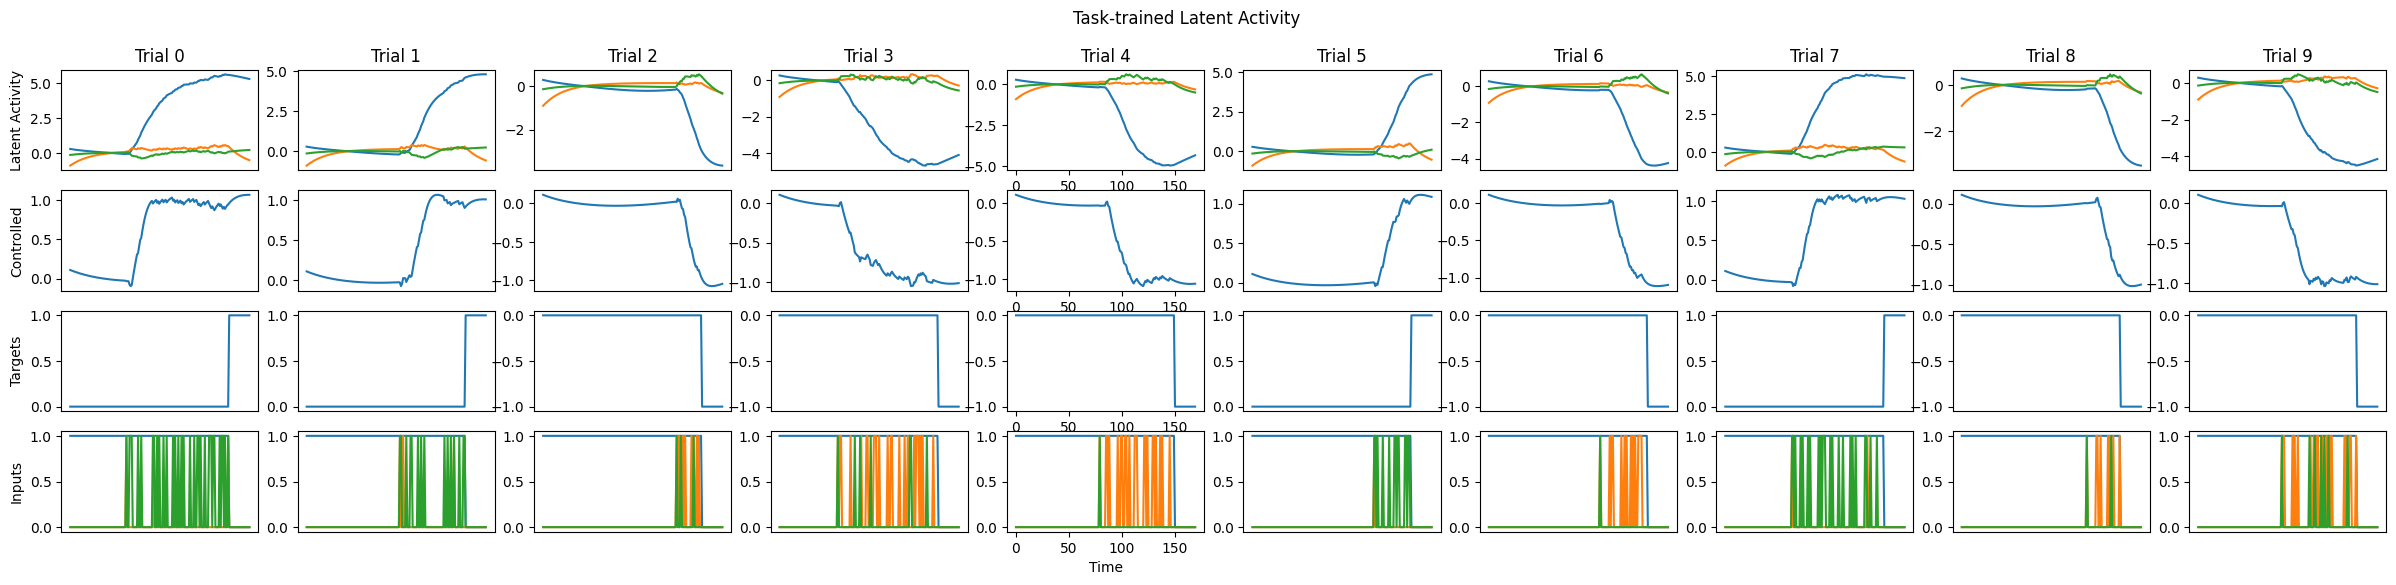

In [2]:
from ctd.comparison.analysis.tt.tt import Analysis_TT
import matplotlib.pyplot as plt
import numpy as np
import torch

# lr rank 2, total dimension 64 (better than total dimension 128)
lr2_pc = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PClicks_lr_grid_final/max_epochs=3000_weight_decay=1.00E-05_learning_rate=2.00E-04_noise=0.00E+00_seed=0_rank=2_latent_size=10_delta_t=1.00E-02_gamma=5.00E-02"

lr2_pc = Analysis_TT(run_name = "rank2_64", filepath = lr2_pc + "/")

lr2_pc.plot_trial_io(num_trials=10)

In [3]:
def plot_flow_fieldLR(self, latents_range: list, num_points:int, input_field: np.array=None,
                          vec1: np.array=None, vec2: np.array=None, orth=False, sizes=1.):
        """
        Plot 2d flow field and eventually fixed points for a rank 2 LowRankRNN. Can plot the affine flow field in presence of a
        constant input with argument input.
        
        :param vec1: None or a numpy array of shape (hidden_size). If None, will be taken as vector m1 of the network
        :param vec2: same with m2
        :param input: None or torch tensor of shape (n_inputs), provides constant input for plotting affine flow field
        :param orth: bool, if True, start by orthogonalizing (vec1, vec2)
        :param sizes: float, general scaling factor for arrows
        
        """
        
        model = self.wrapper.model
        lr_cell = model.cell
        m = lr_cell.recW2.weight
        n = lr_cell.recW1.weight.t()
        
        if vec1 is None:
            vec1 = m[:, 0].squeeze().detach().numpy()
        if vec2 is None:
            vec2 = m[:, 1].squeeze().detach().numpy()
            
        m = m.detach().numpy()
        n = n.detach().numpy()
        
        # Orthogonalization of the basis vec1, vec2, I - gram schmidt
        if orth:
            vec2 = vec2 - (vec2 @ vec1) * vec1 / (vec1 @ vec1)
        if input_field is not None:
            # inpW.weight has dimension (input x hidden)
            I_matrix = lr_cell.inpW.weight.detach().numpy()
            I = input_field @ I_matrix.T
            I_orth = I - (I @ vec1) * vec1 / (vec1 @ vec1) - (I @ vec2) * vec2 / (vec2 @ vec2)
        else:
            I = np.zeros(model.latent_size)
            I_orth = np.zeros(model.latent_size)
            
        # Rescaling the space
        r1 = model.latent_size / (vec1 @ vec1)
        r2 = model.latent_size / (vec2 @ vec2)
            
        # Define the grid
        x = np.linspace(latents_range[0][0], latents_range[0][1], num_points+1)
        y = np.linspace(latents_range[1][0], latents_range[1][1], num_points+1)
        x_mpts = (x[1:] + x[:-1]) / 2
        y_mpts = (y[1:] + y[:-1]) / 2
        field = np.zeros((num_points, num_points, 2))
        U, V = np.meshgrid(x_mpts, y_mpts)
        
        fig, ax = plt.subplots()
        
        # BUG: potentially don't think i need it...
        # adjust shape of input field for my model
        # input_field = torch.unsqueeze(I, 0)
        
        # velocity field from the defining ODE
        def dh_dt(I, hidden):
            # using all in numpy for speed
            return -hidden + m @ (n.T @ np.tanh(hidden)) / model.latent_size + I + lr_cell.bias.detach().numpy()
        
        # Compute flow in each point of the grid
        for i, x in enumerate(x_mpts):
            for j, y in enumerate(y_mpts):
                hidden = r1 * x * vec1 + r2 * y * vec2 + I_orth
                # NOTE: velocity specific to a lrRNN
                delta = dh_dt(I, hidden)
                field[j, i, 0] = delta @ vec1
                field[j, i, 1] = delta @ vec2
        ax.streamplot(x_mpts, y_mpts, field[:, :, 0], field[:, :, 1], color='white', density=0.5, arrowsize=sizes,
                      linewidth=sizes*.8)
        norm_field = np.sqrt(field[:, :, 0] ** 2 + field[:, :, 1] ** 2)
        mappable = ax.pcolor(U, V, norm_field, cmap=plt.get_cmap('pink'))
        
        # project the trajectories onto vec1 and vec2
        
        return ax, mappable

(<Axes: >, <matplotlib.collections.PolyQuadMesh at 0x15523083cf70>)

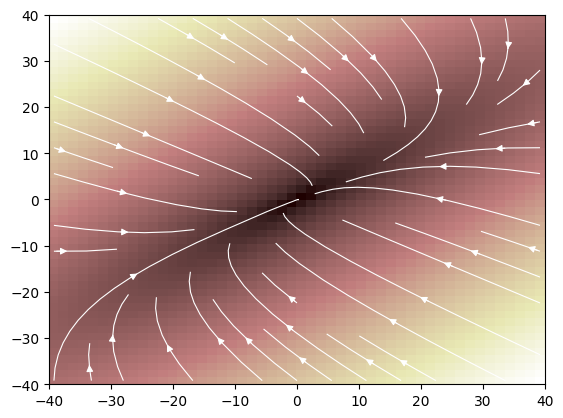

In [4]:
# plot the flow fields
plot_flow_fieldLR(lr2_pc, latents_range=[[-40,40],[-40,40]], num_points=50, input_field=np.array([1,1,1]),
                          vec1=None, vec2=None, orth=False, sizes=1.)